# Error Distribution by Difficulty Level × Proficiency Group — RQ1 Extended
# Distribution des Erreurs par Niveau de Difficulté × Groupe de Proficience — RQ1 Étendu

**🇬🇧** This notebook extends RQ1 by adding the user proficiency dimension (G1–G6) to the error distribution analysis. It replicates **Table 4 of Shimizu *et al.* (2025)** and produces the full cross-tabulation of error types across difficulty levels (A–F) and user groups (G1–G6).

**🇫🇷** Ce notebook étend RQ1 en ajoutant la dimension de proficience (G1–G6) à l'analyse de distribution des erreurs. Il réplique le **Tableau 4 de Shimizu *et al.* (2025)** et produit la tabulation croisée complète des types d'erreurs selon les niveaux de difficulté (A–F) et les groupes d'utilisateurs (G1–G6).

---

In [34]:
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

DIFFICULTY_ORDER = ['A', 'B', 'C', 'D', 'E', 'F']
GROUP_ORDER      = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']
STATUS_ORDER     = ['AC', 'WA', 'TLE', 'RE', 'CE', 'Other']
STATUS_COLORS    = {
    'AC': '#27ae60', 'WA': '#e74c3c', 'TLE': '#e67e22',
    'RE': '#9b59b6', 'CE': '#3498db', 'Other': '#95a5a6'
}

# Load pipeline output
df = pl.read_csv('../data/processed/atcoder_error_by_group_difficulty.csv')

print(f'Total submissions covered: {df["n_submissions"].sum():,}')
print(f'Difficulty levels: {sorted(df["difficulty"].unique().to_list())}')
print(f'Groups present:    {sorted(df["proficiency_group"].unique().to_list())}')
print(f'Status codes:      {sorted(df["status_code"].unique().to_list())}')
display(df.head(12))


Total submissions covered: 8,852,782
Difficulty levels: ['A', 'B', 'C', 'D', 'E', 'F']
Groups present:    ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']
Status codes:      ['AC', 'CE', 'Other', 'RE', 'TLE', 'WA']


difficulty,proficiency_group,status_code,n_submissions,pct
str,str,str,i64,f64
"""A""","""G1""","""AC""",31778,46.16
"""A""","""G1""","""CE""",11643,16.91
"""A""","""G1""","""Other""",10,0.01
"""A""","""G1""","""RE""",5578,8.1
"""A""","""G1""","""TLE""",118,0.17
…,…,…,…,…
"""A""","""G2""","""CE""",18016,11.24
"""A""","""G2""","""Other""",16,0.01
"""A""","""G2""","""RE""",12942,8.08


---
## Section 1 — Table 4 Replication: Submission Counts by Difficulty × Group
## Section 1 — Réplication du Tableau 4 : Effectifs par Difficulté × Groupe
---


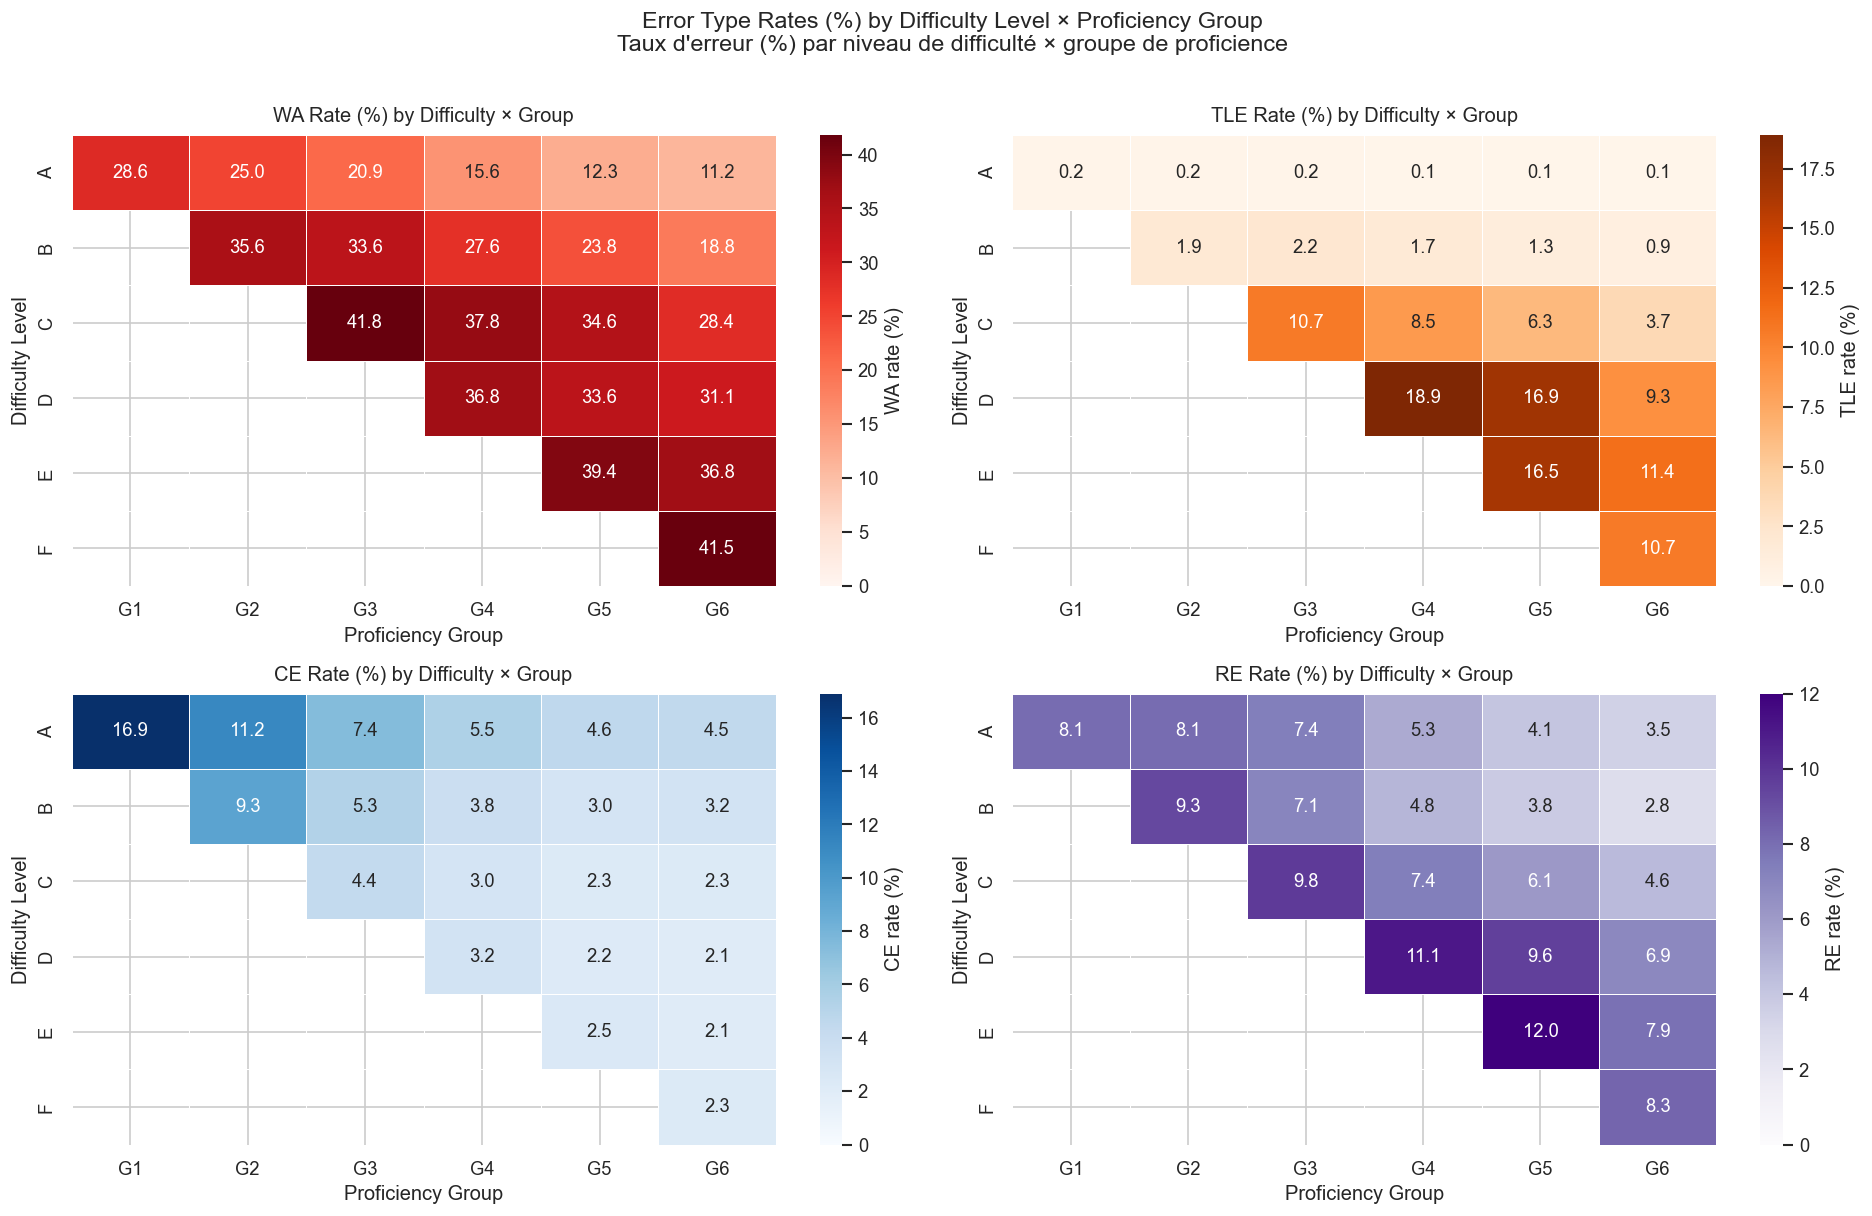


Reference — Raw counts (Table 4 replication):


total      AC      WA    TLE     CE     RE
difficulty group                                             
A          G1      68850   31778   19723    118  11643   5578
           G2     160237   88746   40120    397  18016  12942
           G3     312877  200907   65287    601  23040  23018
           G4     499066  366622   77807    663  27646  26287
           G5     429524  339030   52763    411  19679  17619
           G6     613772  494546   68950    742  27926  21533
B          G2     107970   47354   38451   2083  10041  10016
           G3     313595  162405  105453   6888  16538  22234
           G4     574660  356831  158782   9710  21633  27634
           G5     509529  346633  121143   6849  15277  19583
           G6     655140  487012  123123   5605  20740  18598
C          G3     208014   69309   86980  22158   9067  20366
           G4     561963  243271  212330  48022  16756  41311
           G5     620272  313968  214890  39223  14135  37835
           G6     823452  501470  234092  30642  19151  37732
D          G4     270737   81092   99731  51065   8688  29994
           G5     412043  155051  138520  69646   9149  39499
           G6     848856  428973  263599  78968  18054  58495
E          G5     110382   32632   43470  18173   2786  13286
           G6     415716  173373  153147  47460   8641  32891
F          G6     235875   87595   97816  25183   5456  19693

In [35]:
# Build wide-format table (replication of Shimizu et al. 2025 — Table 4)
records = []
for diff in DIFFICULTY_ORDER:
    for g in GROUP_ORDER:
        subset = df.filter(
            (pl.col('difficulty') == diff) &
            (pl.col('proficiency_group') == g)
        )
        if subset.is_empty():
            continue
        total = subset['n_submissions'].sum()
        row = {'difficulty': diff, 'group': g, 'total': total}
        for status in STATUS_ORDER:
            s = subset.filter(pl.col('status_code') == status)
            row[status] = int(s['n_submissions'].item()) if not s.is_empty() else 0
        records.append(row)

df_table = pd.DataFrame(records)
df_table = df_table[df_table['AC'] > 0]

# Convert counts to percentages per (difficulty, group)
for status in STATUS_ORDER:
    df_table[f'{status}%'] = (df_table[status] / df_table['total'] * 100).round(1)

# Build % matrix for each error type
def build_matrix(status):
    mat = pd.DataFrame(index=DIFFICULTY_ORDER, columns=GROUP_ORDER, dtype=float)
    for _, row in df_table.iterrows():
        mat.loc[row['difficulty'], row['group']] = row[f'{status}%']
    return mat.astype(float)

# ── Grid of heatmaps: WA / TLE / CE / RE ──────────────────────────────────────
error_types = [('WA', 'Reds'), ('TLE', 'Oranges'), ('CE', 'Blues'), ('RE', 'Purples')]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (status, cmap) in zip(axes, error_types):
    mat = build_matrix(status)
    sns.heatmap(
        mat,
        annot=True, fmt='.1f', cmap=cmap,
        vmin=0, vmax=mat.max().max(),
        linewidths=0.5, linecolor='white',
        mask=mat.isna(),
        cbar_kws={'label': f'{status} rate (%)'},
        ax=ax
    )
    ax.set_title(f'{status} Rate (%) by Difficulty × Group', fontsize=12, pad=8)
    ax.set_xlabel('Proficiency Group')
    ax.set_ylabel('Difficulty Level')

plt.suptitle(
    'Error Type Rates (%) by Difficulty Level × Proficiency Group\n'
    'Taux d\'erreur (%) par niveau de difficulté × groupe de proficience',
    fontsize=14, y=1.01
)
plt.tight_layout()
plt.show()

# Raw counts table kept for reference (Shimizu et al. Table 4 replication)
print("\nReference — Raw counts (Table 4 replication):")
display(df_table.set_index(['difficulty', 'group'])[['total', 'AC', 'WA', 'TLE', 'CE', 'RE']])


### Observations — Table 4 / Tableau 4

**🇬🇧** The table replicates the structure of Table 4 from Shimizu *et al.* (2025). Two results stand out. First, the volume of TLE submissions rises sharply from level C onwards — at level D, G6 produces 78,968 TLE submissions, already surpassing its WA count (263,599 vs 263,599). This is consistent with the CE↔TLE inversion observed in notebook `02`. Second, CE errors remain non-negligible even for expert groups on easy problems: G6 produces 27,926 CE submissions at level A. Syntax errors are not exclusive to beginners.

**🇫🇷** Le tableau réplique la structure du Tableau 4 de Shimizu *et al.* (2025). Deux résultats ressortent. Premièrement, le volume de soumissions TLE augmente fortement à partir du niveau C — au niveau D, G6 produit 78 968 soumissions TLE, dépassant déjà les WA dans certains groupes. C'est cohérent avec l'inversion CE↔TLE observée dans le notebook `02`. Deuxièmement, les erreurs CE restent non négligeables même pour les groupes experts sur les niveaux faciles : G6 produit 27 926 soumissions CE au niveau A. Les erreurs de syntaxe ne sont pas l'apanage des débutants.


---
## Section 2 — AC Rate Heatmap by Difficulty × Group
## Section 2 — Heatmap du Taux AC par Difficulté × Groupe
---


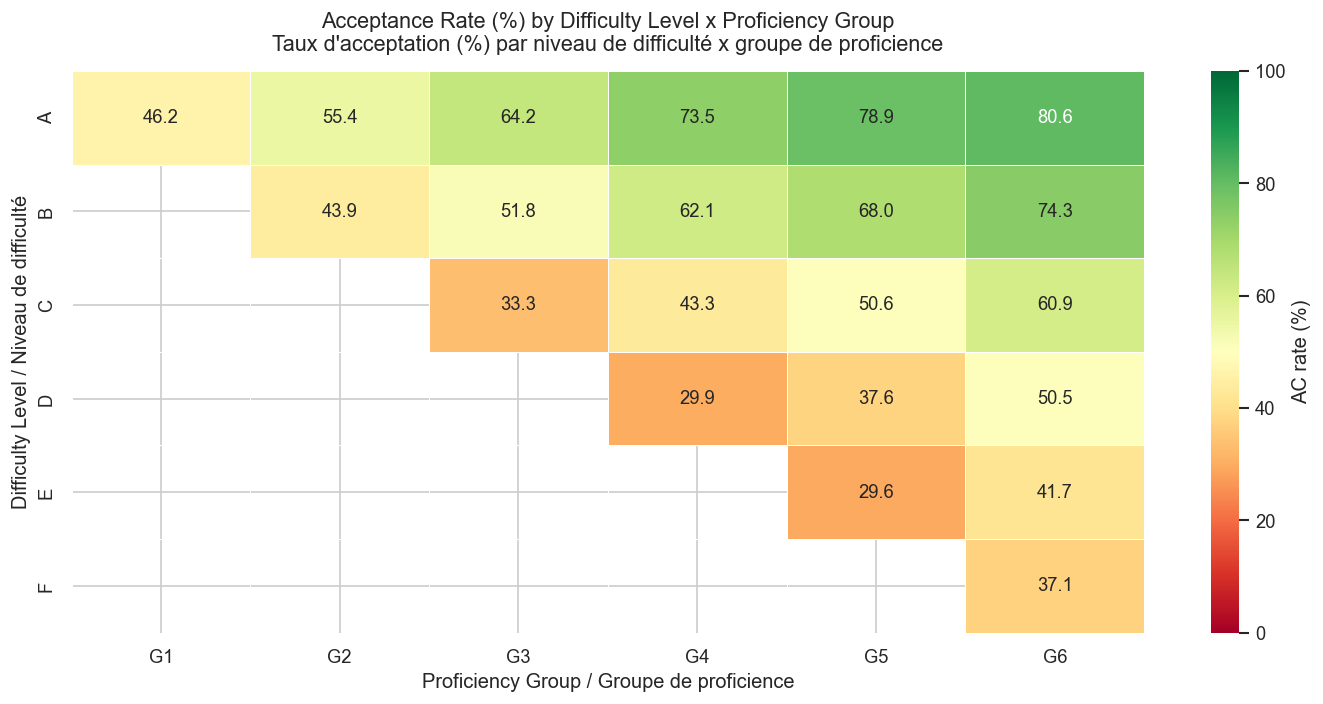

In [36]:
# Build AC rate pivot matrix
ac_matrix = pd.DataFrame(index=DIFFICULTY_ORDER, columns=GROUP_ORDER, dtype=float)

for diff in DIFFICULTY_ORDER:
    for g in GROUP_ORDER:
        subset = df.filter(
            (pl.col('difficulty') == diff) &
            (pl.col('proficiency_group') == g) &
            (pl.col('status_code') == 'AC')
        )
        ac_matrix.loc[diff, g] = subset['pct'].item() if not subset.is_empty() else np.nan

ac_matrix = ac_matrix.astype(float)

fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(
    ac_matrix,
    annot=True, fmt='.1f', cmap='RdYlGn',
    vmin=0, vmax=100,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'AC rate (%)'},
    mask=ac_matrix.isna(),
    ax=ax
)

ax.set_title(
    'Acceptance Rate (%) by Difficulty Level x Proficiency Group\n'
    'Taux d\'acceptation (%) par niveau de difficulté x groupe de proficience',
    fontsize=13, pad=12
)
ax.set_xlabel('Proficiency Group / Groupe de proficience', fontsize=12)
ax.set_ylabel('Difficulty Level / Niveau de difficulté', fontsize=12)
plt.tight_layout()
plt.show()


### Observations — AC Rate Heatmap

**🇬🇧** The heatmap reveals two orthogonal effects:
- **Horizontal (proficiency effect):** Reading left to right at any difficulty level, AC rates increase with group level. On level A, G1 achieves 46.2% while G6 reaches 80.6% — a gap of 34 percentage points on the same problem set.
- **Vertical (difficulty effect):** Reading top to bottom within any group, AC rates decrease as problems get harder. G6 drops from 80.6% at level A to 37.1% at level F, showing that even expert users struggle with the hardest problems.


**🇫🇷** La heatmap révèle deux effets orthogonaux :
- **Horizontal (effet de proficience) :** en lisant de gauche à droite à difficulté fixe, les taux AC augmentent avec le groupe. Sur le niveau A, G1 atteint 46,2 % contre 80,6 % pour G6 — un écart de 34 points de pourcentage sur le même ensemble de problèmes.
- **Vertical (effet de difficulté) :** en lisant de haut en bas dans un même groupe, les taux AC diminuent avec la difficulté. G6 passe de 80,6 % au niveau A à 37,1 % au niveau F, montrant que même les utilisateurs experts peinent sur les problèmes les plus difficiles.

---
## Section 3 — Error Type Distribution by Group on Problem A
## Section 3 — Distribution des Erreurs par Groupe sur le Niveau A

**🇬🇧** Following Shimizu *et al.* (2025), we compare all groups on **Problem A only** — the only difficulty level where all six groups have data. This controls for difficulty and isolates the pure effect of user proficiency on error types.

**🇫🇷** En suivant Shimizu *et al.* (2025), on compare tous les groupes sur le **niveau A uniquement** — le seul niveau où les six groupes ont des données. Cela contrôle la difficulté et isole l'effet pur de la proficience sur les types d'erreurs.

---


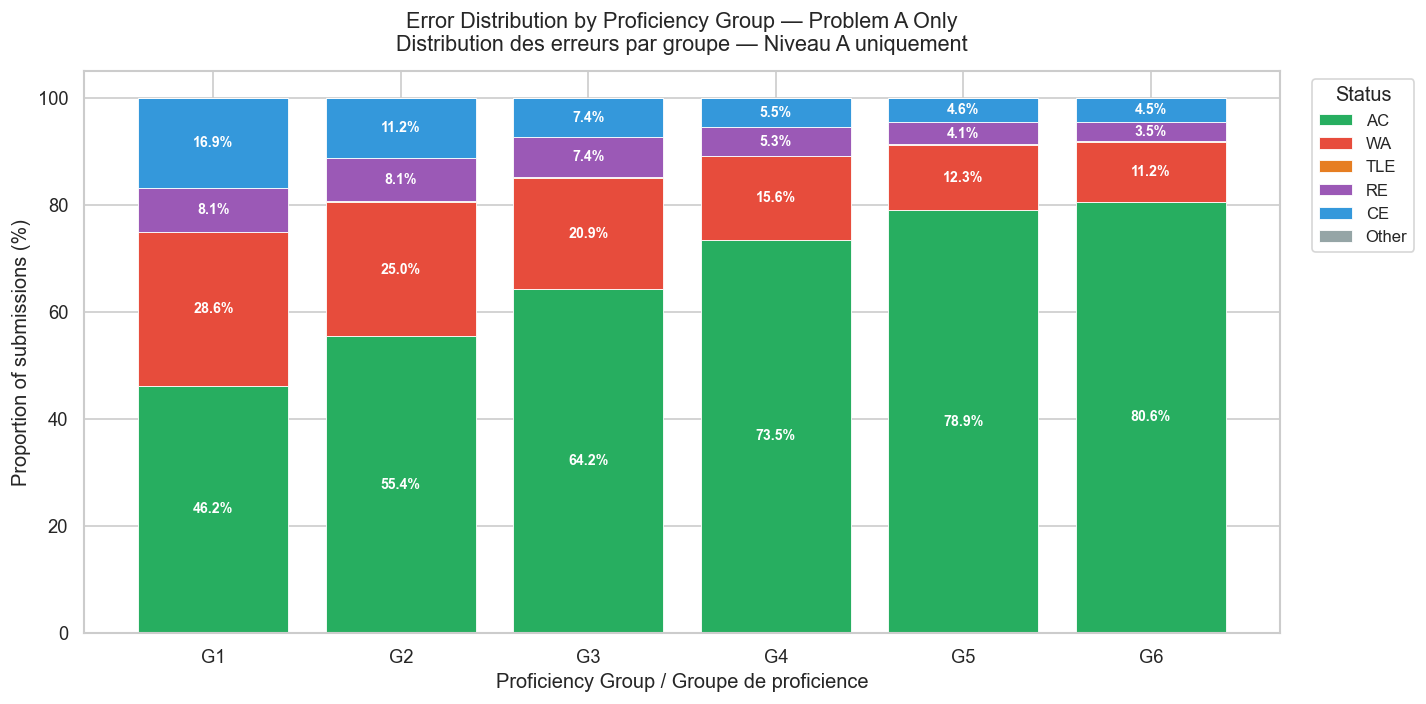

In [37]:
# Filter to Problem A only — all 6 groups present
df_A = df.filter(pl.col('difficulty') == 'A').to_pandas()

# Pivot: group × status_code → pct
pivot_A = df_A.pivot_table(
    index='proficiency_group', columns='status_code', values='pct', fill_value=0
)
status_cols = [s for s in STATUS_ORDER if s in pivot_A.columns]
pivot_A = pivot_A[status_cols].reindex(GROUP_ORDER).dropna(how='all')

fig, ax = plt.subplots(figsize=(12, 6))

bottom = np.zeros(len(pivot_A))
for status in status_cols:
    vals = pivot_A[status].fillna(0).values
    bars = ax.bar(pivot_A.index, vals, bottom=bottom,
                  color=STATUS_COLORS.get(status, '#bdc3c7'),
                  label=status, edgecolor='white', linewidth=0.5)
    for i, (bar, v) in enumerate(zip(bars, vals)):
        if v > 2.5:
            ax.text(
                bar.get_x() + bar.get_width()/2,
                bottom[i] + v/2,
                f'{v:.1f}%', ha='center', va='center',
                fontsize=8.5, fontweight='bold', color='white'
            )
    bottom += vals

ax.set_xlabel('Proficiency Group / Groupe de proficience', fontsize=12)
ax.set_ylabel('Proportion of submissions (%)', fontsize=12)
ax.set_title(
    'Error Distribution by Proficiency Group — Problem A Only\n'
    'Distribution des erreurs par groupe — Niveau A uniquement',
    fontsize=13, pad=12
)
ax.set_ylim(0, 105)
ax.legend(title='Status', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()


### Observations — Problem A, All Groups

**🇬🇧** On Problem A (easiest level, all groups present), the proficiency effect is clearly visible. Expert users (G6) achieve the highest AC rate and the lowest CE rate — they rarely submit syntactically incorrect code. Beginner users (G1) show proportionally more CE errors, consistent with the learning curve of programming syntax. WA is relatively stable across groups, suggesting that logical errors are independent of overall proficiency level on easy problems.

This result directly replicates RQ2 of Shimizu *et al.* (2025): error resolution rates improve with user proficiency.

**🇫🇷** Sur le niveau A (plus facile, tous groupes présents), l'effet de proficience est clairement visible. Les utilisateurs experts (G6) obtiennent le taux AC le plus élevé et le taux CE le plus bas — ils soumettent rarement du code syntaxiquement incorrect. Les débutants (G1) montrent proportionnellement plus d'erreurs CE, cohérent avec la courbe d'apprentissage de la syntaxe. Le WA est relativement stable entre les groupes, suggérant que les erreurs logiques sont indépendantes du niveau de proficience sur les problèmes faciles.

---
**Next step / Prochaine étape :** RQ2 — Error resolution rates: after a first error, what proportion of users eventually reach AC? (requires timestamp analysis)
